---
tags: [algorithm, machine-learning, variational]
---

# ハイブリッド量子ニューラルネットワーク (HQNN)

このチュートリアルでは、古典ニューラルネットワーク層と量子変分回路層を組み合わせた**ハイブリッド量子ニューラルネットワーク** (HQNN) を Fashion-MNIST データセットで構築します。量子層は Qamomile の `@qkernel` API で定義し、パラメータシフトルールを用いて PyTorch の学習パイプラインに統合します。

## アーキテクチャ

CNN 特徴抽出器・量子層・fusion 分類器の全体を、**最初から end-to-end で学習**します：

```
入力画像 → CNN → π·σ(·) → 量子層 → [CNN特徴, 量子出力] → 分類器 → 出力
```

ここで $\pi \cdot \sigma(\cdot)$ は要素ごとの sigmoid スケーリングを表します。CNN の出力を sigmoid 関数 $\sigma$ に通し $\pi$ を掛けることで、各特徴量を区間 $(0, \pi)$ に写します。これにより量子層に入力する回転角が有界となり、wrap-around による学習の不安定化を防ぎます。

分類器に古典 CNN 特徴と量子期待値の両方を入力する fusion 構造により、CNN と量子層が最初から協調して学習できます。

## インポートとセットアップ

In [1]:
import math
import os

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

import qamomile.circuit as qmc
from qamomile.circuit.algorithm import ry_layer, rz_layer, cz_entangling_layer
import qamomile.observable as qmo
from qamomile.qiskit import QiskitTranspiler

docs_test_mode = os.environ.get("QAMOMILE_DOCS_TEST") == "1"

In [2]:
N_QUBITS = 4
N_LAYERS = 1 if docs_test_mode else 2
N_WEIGHTS_PER_LAYER = N_QUBITS * 3  # 各量子ビットに RZ, RY, RZ
N_WEIGHTS = N_LAYERS * N_WEIGHTS_PER_LAYER

print(f"量子ビット数: {N_QUBITS}, 層数: {N_LAYERS}, 学習パラメータ数: {N_WEIGHTS}")
assert N_QUBITS == 4
assert N_LAYERS == (1 if docs_test_mode else 2)
# N_WEIGHTS = N_LAYERS * N_QUBITS * 3(1層あたり量子ビットごとに RZ + RY + RZ)。
assert N_WEIGHTS == (12 if docs_test_mode else 24)

量子ビット数: 4, 層数: 2, 学習パラメータ数: 24


## @qkernel で変分アンザッツを定義

Qamomile の `@qkernel` デコレータを使ってパラメータ付き量子回路を定義します。回路は以下の構成です：

1. **角度エンコーディング**: 各入力特徴量を対応する量子ビットの RY 回転として埋め込みます。
2. **変分層**: stdlib の層関数を使い、各層で RZ-RY-RZ 回転を適用し、その後 CZ エンタングルメントラダーを実行します。

回路は与えられたオブザーバブルの期待値 $\langle H \rangle$ を計算します。

In [3]:
@qmc.qkernel
def variational_ansatz(
    n_qubits: qmc.UInt,
    n_layers: qmc.UInt,
    inputs: qmc.Vector[qmc.Float],
    weights: qmc.Vector[qmc.Float],
    hamiltonian: qmc.Observable,
) -> qmc.Float:
    q = qmc.qubit_array(n_qubits, name="q")

    # 角度エンコーディング: 古典特徴量を RY 回転で埋め込み
    for i in qmc.range(n_qubits):
        q[i] = qmc.ry(q[i], inputs[i])

    # stdlib の層関数を使った変分層
    for layer_idx in qmc.range(n_layers):
        base = layer_idx * n_qubits * 3
        q = rz_layer(q, weights, base)
        q = ry_layer(q, weights, base + n_qubits)
        q = rz_layer(q, weights, base + n_qubits * 2)
        q = cz_entangling_layer(q)

    return qmc.expval(q, hamiltonian)

回路構造を可視化してみましょう。`inline=False` により stdlib の層関数がコンパクトなボックスとして表示されます：

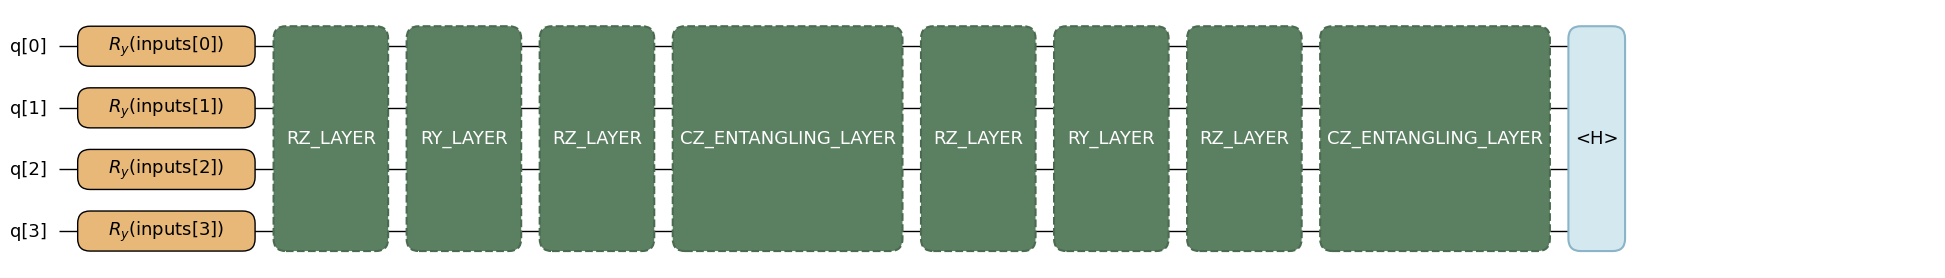

In [4]:
variational_ansatz.draw(
    n_qubits=N_QUBITS,
    n_layers=N_LAYERS,
    hamiltonian=qmo.Z(0),
    fold_loops=False,
    inline=False,
)

## トランスパイルとリソース推定

各量子ビットのオブザーバブル ($\langle Z_i \rangle$) を定義し、それぞれに対する executable を作成します。
Qiskit の estimator は回路と同じ量子ビット数のオブザーバブルを要求するため、
`Hamiltonian(num_qubits=...)` で回路幅に合わせてパディングします。
`estimate_resources()` を使い、エンジン回路に直接アクセスせずにゲート数を確認できます。

In [5]:
observables = []
for i in range(N_QUBITS):
    obs = qmo.Hamiltonian(num_qubits=N_QUBITS)
    obs.add_term((qmo.PauliOperator(qmo.Pauli.Z, i),), 1.0)
    observables.append(obs)

transpiler = QiskitTranspiler()

executables = [
    transpiler.transpile(
        variational_ansatz,
        bindings={"n_qubits": N_QUBITS, "n_layers": N_LAYERS, "hamiltonian": obs},
        parameters=["inputs", "weights"],
    )
    for obs in observables
]

est = variational_ansatz.estimate_resources(
    inputs={"n_qubits": N_QUBITS, "n_layers": N_LAYERS},
)
print(est)
assert est.qubits == 4
# 入力 RY 4 + 2 層 * (RZ 4 + RY 4 + RZ 4) = 1-qubit 回転 28 個。
assert est.gates.single_qubit == (16 if docs_test_mode else 28)
# 2 層 * 3 CZ(4 量子ビット線形チェーン)= 2-qubit Clifford 6 個。
assert est.gates.two_qubit == (3 if docs_test_mode else 6)
assert est.gates.total == (19 if docs_test_mode else 34)
assert est.gates.rotation_gates == (16 if docs_test_mode else 28)

ResourceEstimate(width=WidthResources(input_qubits=0, allocated_qubits=4, clean_ancilla_qubits=0, dirty_ancilla_qubits=0, peak_qubits=4), gates=GateResources(total=34, single_qubit=28, two_qubit=6, multi_qubit=0, clifford=6, rotation=28, t=0, toffoli=0, non_clifford=28), depth=DepthResources(depth=14, clifford_depth=6, rotation_depth=7, t_depth=0, toffoli_depth=0, non_clifford_depth=7, measurement_depth=1, gate_depth=13, reset_depth=0), calls=CallResources(calls_by_name={'expval': 1}, queries_by_name={'expval': 1}), assumptions=(ResourceAssumption(message='sequential loop-body depth may over-serialize active iterations whose per-wire completion layers cannot be composed exactly', source='for'), ResourceAssumption(message='expectation-value gate and shot costs depend on observable grouping, basis rotations, and executor sampling policy', source='ExpvalOp'), ResourceAssumption(message='aggregate latency may over-serialize a later wire dependency and therefore overestimate depth', source=

## 量子フォワードパス

フォワードパスでは、回路パラメータに具体的な値をバインドし、Qamomile の executor を使って各量子ビットの $\langle Z_i \rangle$ を評価します。

In [6]:
executor = transpiler.executor()


def quantum_forward(input_vals: np.ndarray, weight_vals: np.ndarray) -> np.ndarray:
    """各量子ビットの <Z_i> を評価する。

    Args:
        input_vals: 特徴量の値、shape (N_QUBITS,)。
        weight_vals: 学習可能な重み、shape (N_WEIGHTS,)。

    Returns:
        期待値、shape (N_QUBITS,)。
    """
    runtime_bindings = {
        "inputs": list(input_vals),
        "weights": list(weight_vals),
    }
    return np.array(
        [exe.run(executor, bindings=runtime_bindings).result() for exe in executables],
        dtype=float,
    )

In [7]:
# 動作テスト: ランダムな入力と重み
rng = np.random.default_rng(42)
test_inputs = rng.uniform(-np.pi, np.pi, N_QUBITS)
test_weights = rng.uniform(-np.pi, np.pi, N_WEIGHTS)

expvals = quantum_forward(test_inputs, test_weights)
print("期待値:", expvals)
# Z の期待値は [-1, 1]、量子ビット 1 個に 1 値。
assert expvals.shape == (N_QUBITS,)
assert all(-1.0 <= float(e) <= 1.0 for e in expvals)

期待値: [-0.70960489  0.61071606  0.43586927  0.42650987]


## パラメータシフトルールによる勾配計算

PyTorch の autograd で量子層を学習するには、すべてのパラメータに関する期待値の勾配が必要です。$e^{-i\theta G/2}$ 形式のゲートに対して、**パラメータシフトルール**は厳密な勾配公式を与えます：

$$
\frac{\partial}{\partial \theta_k} \langle Z_i \rangle
= \frac{1}{2} \Big[
    \langle Z_i \rangle\big|_{\theta_k + \pi/2}
  - \langle Z_i \rangle\big|_{\theta_k - \pi/2}
\Big]
$$

これをカスタム `torch.autograd.Function` として実装し、PyTorch が量子層を通じて誤差逆伝播できるようにします。メモリ効率のため、パラメータのシフトはインプレースで行います。

In [8]:
SHIFT = math.pi / 2


class QuantumFunction(torch.autograd.Function):
    """PyTorch と量子回路を橋渡しするカスタム autograd 関数。"""

    @staticmethod
    def forward(ctx, inputs: torch.Tensor, weights: torch.Tensor) -> torch.Tensor:
        ctx.save_for_backward(inputs, weights)
        # バッチ内の各サンプルに対して回路を評価
        batch_results = []
        weights_np = weights.detach().cpu().numpy()
        for inp in inputs:
            expvals = quantum_forward(inp.detach().cpu().numpy(), weights_np)
            batch_results.append(expvals)
        return torch.tensor(np.array(batch_results), dtype=inputs.dtype, device=inputs.device)

    @staticmethod
    def backward(ctx, grad_output: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        inputs, weights = ctx.saved_tensors
        weights_np = weights.detach().cpu().numpy().copy()

        grad_inputs = torch.zeros_like(inputs)
        grad_weights = torch.zeros(weights.shape[0], dtype=weights.dtype, device=weights.device)

        for b, inp in enumerate(inputs):
            inp_np = inp.detach().cpu().numpy().copy()
            g_out = grad_output[b].detach().cpu().numpy()  # shape (N_QUBITS,)

            # 重みに関する勾配（コピー回避のためインプレースシフト）
            for k in range(len(weights_np)):
                weights_np[k] += SHIFT
                fwd_plus = quantum_forward(inp_np, weights_np)
                weights_np[k] -= 2 * SHIFT
                fwd_minus = quantum_forward(inp_np, weights_np)
                weights_np[k] += SHIFT  # 元の値に復元

                param_grad = (fwd_plus - fwd_minus) / 2.0  # shape (N_QUBITS,)
                grad_weights[k] += np.dot(g_out, param_grad)

            # 入力に関する勾配（コピー回避のためインプレースシフト）
            for k in range(len(inp_np)):
                inp_np[k] += SHIFT
                fwd_plus = quantum_forward(inp_np, weights_np)
                inp_np[k] -= 2 * SHIFT
                fwd_minus = quantum_forward(inp_np, weights_np)
                inp_np[k] += SHIFT  # 元の値に復元

                input_grad = (fwd_plus - fwd_minus) / 2.0
                grad_inputs[b, k] = np.dot(g_out, input_grad)

        return grad_inputs, grad_weights

## 量子層を PyTorch モジュールとして定義

autograd 関数を標準的な `nn.Module` でラップし、他の層と組み合わせられるようにします。

In [9]:
class QLayer(nn.Module):
    """Qamomile 変分回路をラップする PyTorch モジュール。"""

    def __init__(self, n_weights: int):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(n_weights) * 0.1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return QuantumFunction.apply(x, self.weights)

## データの準備 (Fashion-MNIST)

[Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist) データセットから4つの視覚的に異なるクラスのサブセットを使用します。Fashion-MNIST は 28x28 のグレースケール衣類画像で構成されるデータセットです。

計算時間を抑えるため、4クラス（T-shirt、Trouser、Sandal、Bag）を選択し、各クラス60枚の訓練データ、30枚のテストデータを使用します。

In [10]:
N_CLASSES = 4
SELECTED_CLASSES = [0, 1, 5, 8]  # T-shirt, Trouser, Sandal, Bag
CLASS_NAMES = ["T-shirt", "Trouser", "Sandal", "Bag"]
N_TRAIN_PER_CLASS = 1 if docs_test_mode else 60
N_TEST_PER_CLASS = 1 if docs_test_mode else 30

def subset_dataset(dataset, classes, n_per_class):
    """指定クラスからランダムにサブセットを抽出する。"""
    images, labels = [], []
    rng_data = np.random.default_rng(0)
    # dataset.targets でインデックスを取得（全画像のロード・変換を回避）
    targets = dataset.targets
    if isinstance(targets, torch.Tensor):
        targets = targets.numpy()
    else:
        targets = np.array(targets)
    for new_label, orig_label in enumerate(classes):
        class_indices = np.where(targets == orig_label)[0]
        chosen = rng_data.choice(class_indices, size=n_per_class, replace=False)
        for idx in chosen:
            img, _ = dataset[int(idx)]
            images.append(img)
            labels.append(new_label)
    return torch.stack(images), torch.tensor(labels)


if docs_test_mode:
    # docs testでは、CI runnerごとの29 MBのFashion-MNISTダウンロードを避けつつ、
    # hybrid forward/backward/updateの全経路を実行する。
    data_generator = torch.Generator().manual_seed(0)
    X_train = torch.rand((N_CLASSES, 1, 28, 28), generator=data_generator)
    X_test = torch.rand((N_CLASSES, 1, 28, 28), generator=data_generator)
    y_train = torch.arange(N_CLASSES)
    y_test = torch.arange(N_CLASSES)
else:
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.2860,), (0.3530,)),
    ])
    # 永続キャッシュディレクトリを使用（再ダウンロードを回避）
    _data_root = os.path.join(os.path.expanduser("~"), ".cache", "fashion_mnist")
    full_train = datasets.FashionMNIST(
        root=_data_root, train=True, download=True, transform=transform
    )
    full_test = datasets.FashionMNIST(
        root=_data_root, train=False, download=True, transform=transform
    )
    X_train, y_train = subset_dataset(
        full_train, SELECTED_CLASSES, N_TRAIN_PER_CLASS
    )
    X_test, y_test = subset_dataset(full_test, SELECTED_CLASSES, N_TEST_PER_CLASS)

print(f"訓練データ: {X_train.shape}, テストデータ: {X_test.shape}")
# 4 クラス × N_PER_CLASS サンプル; Fashion-MNIST は 1x28x28 グレースケール。
assert X_train.shape == (N_CLASSES * N_TRAIN_PER_CLASS, 1, 28, 28)
assert X_test.shape == (N_CLASSES * N_TEST_PER_CLASS, 1, 28, 28)
print(f"クラス: {CLASS_NAMES}")

訓練データ: torch.Size([240, 1, 28, 28]), テストデータ: torch.Size([120, 1, 28, 28])
クラス: ['T-shirt', 'Trouser', 'Sandal', 'Bag']


## End-to-End ハイブリッドモデル

ハイブリッドモデル全体を**最初から end-to-end で学習**します。CNN 特徴抽出器と量子層が協調学習します。損失関数から分類器、量子層（パラメータシフトルール経由）、CNN へと勾配が流れます。

```
入力画像 → [CNN 特徴抽出器] → π·σ(·) → [量子層] → [CNN特徴, 量子出力] → [分類器] → 出力
```

- **Sigmoid スケーリング**: $\pi \cdot \sigma(\cdot)$ で CNN 出力を $(0, \pi)$ に写し、角度の wrap-around を抑える。
- **Fusion 分類器**: `[CNN特徴, 量子出力]` を結合し、古典と量子の両方の表現を分類器に入力。

In [11]:
class EndToEndHybridHQNN(nn.Module):
    """
    end-to-end 用のハイブリッドモデル（最初から全体を学習）。
    画像 -> CNN特徴 -> 量子層 -> 分類器

    分類器には [古典特徴, 量子出力] を両方入れる fusion 構造。
    CNN と量子層が最初から協調して学習する。
    """

    def __init__(self, n_qubits: int, n_weights: int, n_classes: int):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(1, 4, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(4, 4, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(7 * 7 * 4, n_qubits),
        )
        self.qlayer = QLayer(n_weights)
        self.classifier = nn.Linear(n_qubits * 2, n_classes)

    def forward(self, x: torch.Tensor):
        # CNN特徴を量子層入力の角度へ
        feats = math.pi * torch.sigmoid(self.feature_extractor(x))   # shape: (B, N_QUBITS)
        q_out = self.qlayer(feats)                                   # shape: (B, N_QUBITS)

        fused = torch.cat([feats, q_out], dim=1)                     # shape: (B, 2*N_QUBITS)
        logits = self.classifier(fused)
        return logits, feats, q_out


EPOCHS = 1 if docs_test_mode else 10
BATCH_SIZE = 4

torch.manual_seed(42)
hybrid_model = EndToEndHybridHQNN(N_QUBITS, N_WEIGHTS, N_CLASSES)

optimizer = torch.optim.Adam(hybrid_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train_losses = []
test_accs = []

print(f"=== End-to-End 学習 ({EPOCHS} エポック) ===")
for epoch in range(EPOCHS):
    perm = torch.randperm(len(X_train))
    X_shuf, y_shuf = X_train[perm], y_train[perm]

    epoch_loss = 0.0
    total = 0

    for i in range(0, len(X_shuf), BATCH_SIZE):
        xb = X_shuf[i : i + BATCH_SIZE]
        yb = y_shuf[i : i + BATCH_SIZE]

        optimizer.zero_grad()
        logits, feats, q_out = hybrid_model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        total += len(yb)

    avg_loss = epoch_loss / max(1, math.ceil(total / BATCH_SIZE))
    train_losses.append(avg_loss)

    with torch.no_grad():
        test_logits, _, _ = hybrid_model(X_test)
        test_acc = (test_logits.argmax(1) == y_test).float().mean().item()
        test_accs.append(test_acc)

    print(f"  エポック {epoch + 1}/{EPOCHS}  損失={avg_loss:.4f}  テスト精度={test_acc:.2%}")

=== End-to-End 学習 (10 エポック) ===


  エポック 1/10  損失=1.3356  テスト精度=55.83%


  エポック 2/10  損失=0.9415  テスト精度=97.50%


  エポック 3/10  損失=0.6617  テスト精度=97.50%


  エポック 4/10  損失=0.5081  テスト精度=96.67%


...

  エポック 6/10  損失=0.3461  テスト精度=96.67%


  エポック 7/10  損失=0.3025  テスト精度=96.67%


  エポック 8/10  損失=0.2675  テスト精度=96.67%


  エポック 9/10  損失=0.2436  テスト精度=96.67%


  エポック 10/10  損失=0.2324  テスト精度=97.50%


In [12]:
# 勾配が CNN と量子層の両方に流れているか確認
xb = X_train[:BATCH_SIZE]
yb = y_train[:BATCH_SIZE]

optimizer.zero_grad()
logits, feats, q_out = hybrid_model(xb)
loss = criterion(logits, yb)
loss.backward()

# ``loss.backward()`` で ``.grad`` が populate されるので、torch の stub で
# ``Tensor | None`` と宣言された ``.grad`` を ``assert`` で narrow する。
# ``nn.Sequential.__getitem__`` は torch の stub 上 ``Tensor | None | Module``
# を返す (整数 index と slice の両方を受けるため) ので、まず ``nn.Module`` に
# narrow してから ``.weight`` を取り出す。
first_conv = hybrid_model.feature_extractor[0]
assert isinstance(first_conv, torch.nn.Module)
first_conv_weight = first_conv.weight  # type: ignore[union-attr]
assert first_conv_weight.grad is not None
quantum_grad = hybrid_model.qlayer.weights.grad
assert quantum_grad is not None
print(
    "feature_extractor first conv grad mean:",
    # zuban は stub 上 Tensor の ``.grad.abs()`` チェーンを "Tensor not
    # callable" と判定するが、runtime 側は通常の ``Tensor.abs`` メソッド呼び出し。
    first_conv_weight.grad.abs().mean().item(),  # type: ignore[operator]
)
print("quantum weights grad mean:",
      quantum_grad.abs().mean().item())

optimizer.zero_grad()

feature_extractor first conv grad mean: 0.07927611470222473
quantum weights grad mean: 0.009609604254364967


## 評価

In [13]:
with torch.no_grad():
    q_logits, F_test_e2e, q_outputs = hybrid_model(X_test)
    preds = q_logits.argmax(1)
    quantum_acc = (preds == y_test).float().mean().item()

print(f"end-to-end 量子モデルの精度: {quantum_acc:.2%}")
print()

for c in range(N_CLASSES):
    mask = y_test == c
    class_acc = (preds[mask] == y_test[mask]).float().mean().item()
    print(f"  {CLASS_NAMES[c]}: {class_acc:.2%}")

end-to-end 量子モデルの精度: 97.50%

  T-shirt: 96.67%
  Trouser: 100.00%
  Sandal: 100.00%
  Bag: 93.33%


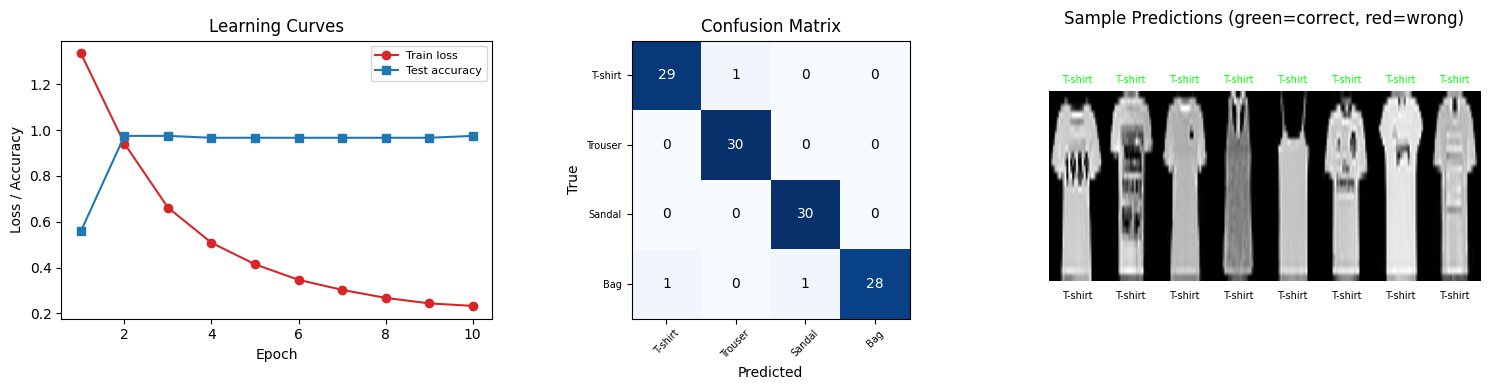

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) Learning curves
ax = axes[0]
epochs_range = range(1, EPOCHS + 1)
ax.plot(epochs_range, train_losses, "o-", color="C3", label="Train loss")
ax.plot(epochs_range, test_accs, "s-", color="C0", label="Test accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss / Accuracy")
ax.set_title("Learning Curves")
ax.legend(fontsize=8)

# (b) Confusion matrix
conf = np.zeros((N_CLASSES, N_CLASSES), dtype=int)
for t, p in zip(y_test.numpy(), preds.numpy()):
    conf[t, p] += 1
axes[1].imshow(conf, cmap="Blues")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].set_title("Confusion Matrix")
axes[1].set_xticks(range(N_CLASSES))
axes[1].set_yticks(range(N_CLASSES))
axes[1].set_xticklabels(CLASS_NAMES, fontsize=7, rotation=45)
axes[1].set_yticklabels(CLASS_NAMES, fontsize=7)
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        axes[1].text(
            j, i, str(conf[i, j]), ha="center", va="center",
            color="white" if conf[i, j] > conf.max() / 2 else "black",
        )

# (c) Sample images with predictions
n_show = min(8, len(X_test))
sample_imgs = X_test[:n_show, 0].numpy()
combined = np.concatenate(sample_imgs, axis=1)
axes[2].imshow(combined, cmap="gray", aspect="auto")
for i in range(n_show):
    color = "lime" if preds[i] == y_test[i] else "red"
    axes[2].text(
        28 * i + 14, -1.5,
        CLASS_NAMES[preds[i].item()],
        ha="center", va="bottom", fontsize=7, color=color,
        clip_on=False,
    )
    # ``Tensor.item()`` は torch の stub 上は ``int | float | bool`` を返す
    # ことになっていて、整数型 tensor でも狭い型に narrow されない。実行時の
    # 値は常に ``int`` のクラスラベルなので、リスト index 用に明示 cast する。
    axes[2].text(
        28 * i + 14, 29,
        CLASS_NAMES[int(y_test[i].item())],
        ha="center", va="top", fontsize=7,
        clip_on=False,
    )
axes[2].set_ylim(33, -8)
axes[2].set_title("Sample Predictions (green=correct, red=wrong)", pad=12)
axes[2].axis("off")

plt.tight_layout()
plt.show()